<a href="https://colab.research.google.com/github/MathusiganSenthan/machine-learning-Group-Pro/blob/Logistic-regression-it22569318/IT22569318.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
# breast_cancer_logistic_regression.py

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [95]:
import joblib

# -------------------------------
# 2. Load Dataset
# -------------------------------
# If using Colab: upload your data.csv first
df = pd.read_csv('/content/drive/MyDrive/Python /IT4010-ML/Assignment/COVID-19_RECOVERY_DATASET.csv')
df = df.iloc[:1000]

# Preview dataset
print("Dataset Preview:")
print(df.head())
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

Dataset Preview:
  patient_id   country region/state  date_reported  age  gender comorbidities  \
0    P000001     India        Sindh          44447   95  Female      Diabetes   
1    P000002  Pakistan       London          43930   92  Female      Diabetes   
2    P000003   Germany       Berlin          44718   78  Female           NaN   
3    P000004     India    Cape Town          44107   36  Female        Cancer   
4    P000005        UK       Berlin          44083   99    Male      Diabetes   

      symptoms_1     symptoms_2     symptoms_3  ... days_to_recovery  \
0          Cough            NaN            NaN  ...               18   
1  Loss of Smell        Fatigue        Fatigue  ...                9   
2       Headache  Loss of Smell  Loss of Smell  ...               27   
3          Cough        Fatigue        Fatigue  ...               25   
4        Fatigue            NaN            NaN  ...               17   

   recovered  death  date_of_recovery date_of_death tests_condu

In [96]:
# -------------------------------
# 3. Preprocessing
# -------------------------------

# Drop mostly-identifiers or irrelevant columns
drop_cols = ['patient_id', 'country', 'region/state', 'date_reported', 'date_of_recovery', 'date_of_death',
             'hospital_name', 'doctor_assigned', 'source_url', 'death' ]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Fill missing categorical values with 'Unknown'
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Fill missing numerical values with median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
imputer = SimpleImputer(strategy='median')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Encode categorical features
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # save encoder if needed later


/tmp/ipykernel_39183/602333165.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [97]:
# Check target distribution
# Removed df['target'] = df['recovered'] to avoid duplicate target columns
print("\nTarget Distribution:")
print(df['recovered'].value_counts()) # Changed to use 'recovered' directly


Target Distribution:
recovered
0.0    750
1.0    250
Name: count, dtype: int64


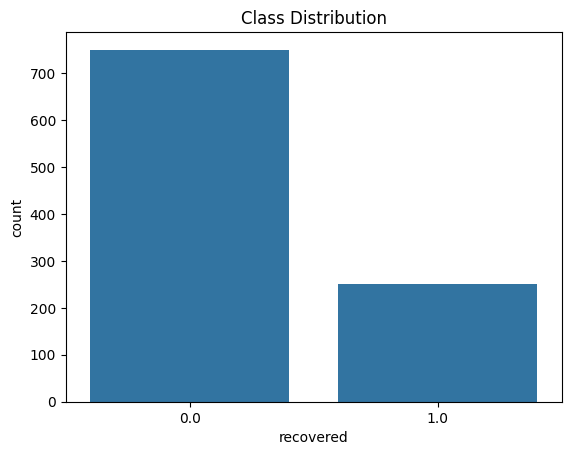

In [98]:
# -------------------------------
# 4. Exploratory Data Analysis
# -------------------------------
# Class distribution
sns.countplot(x='recovered', data=df) # Changed 'target' to 'recovered'
plt.title("Class Distribution")
plt.show()

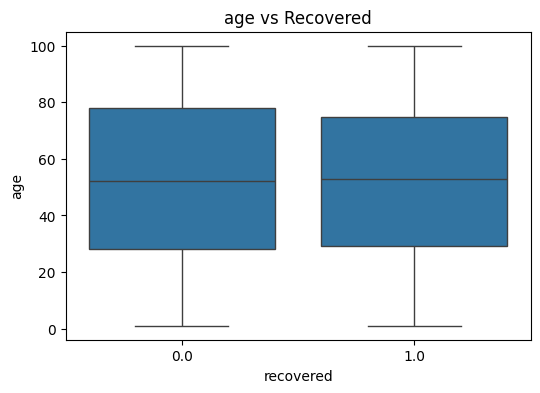

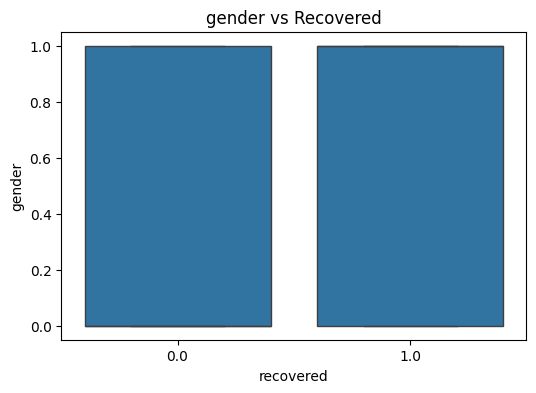

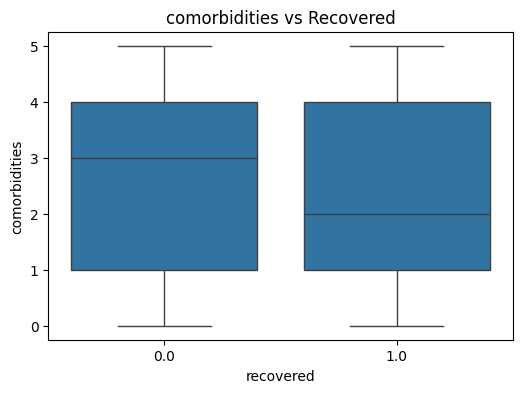

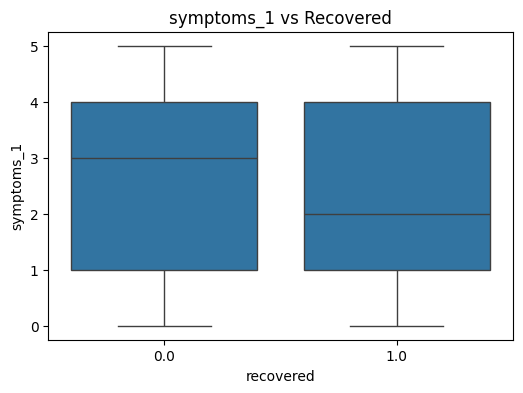

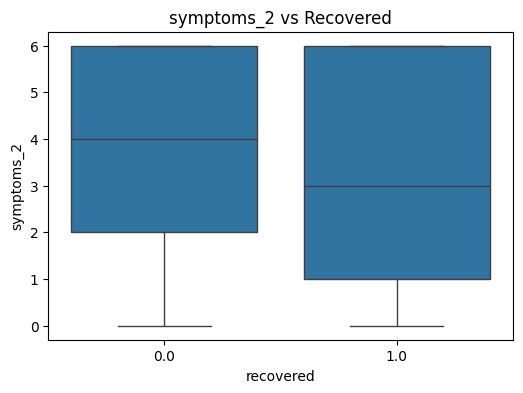

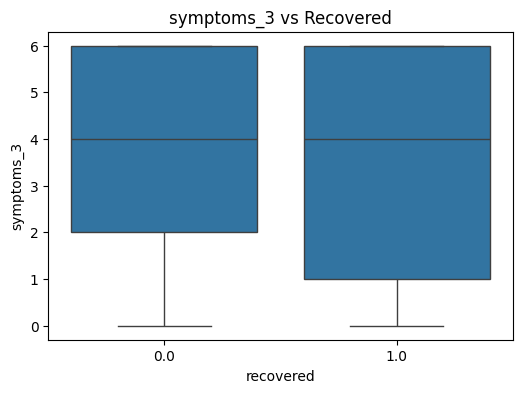

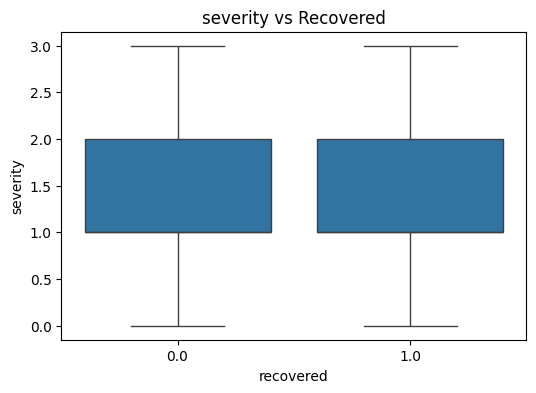

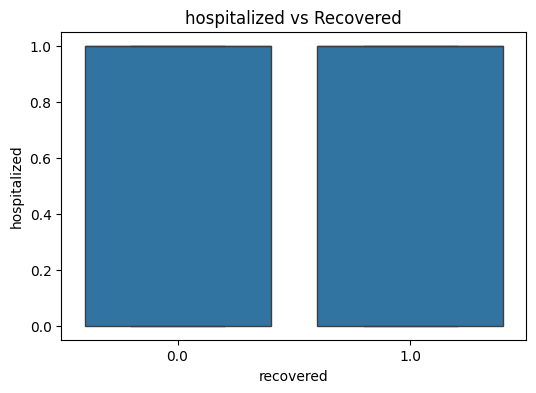

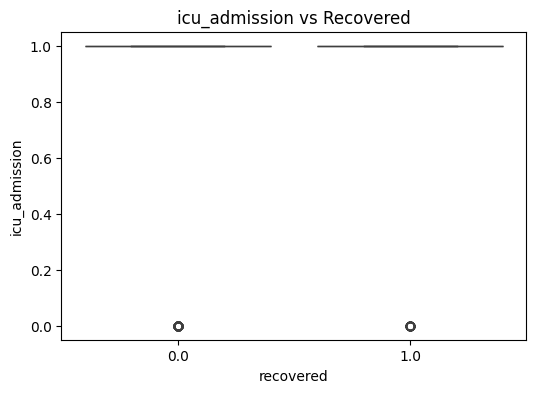

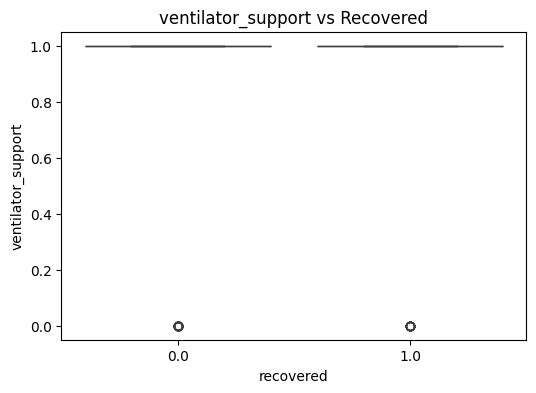

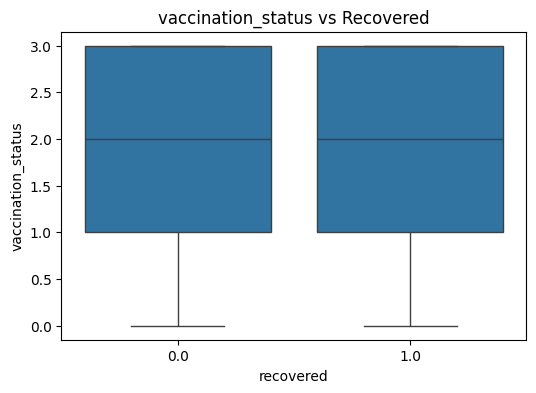

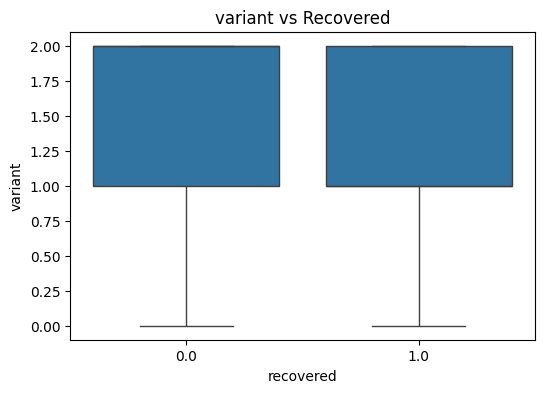

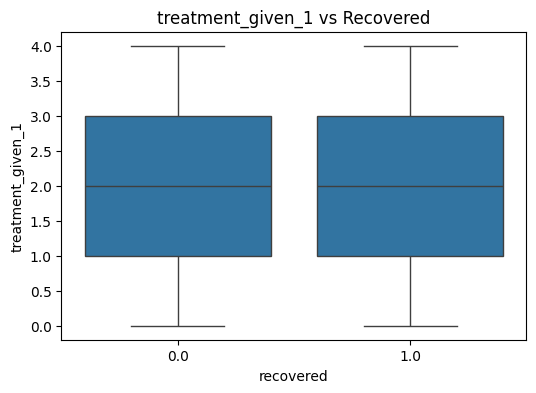

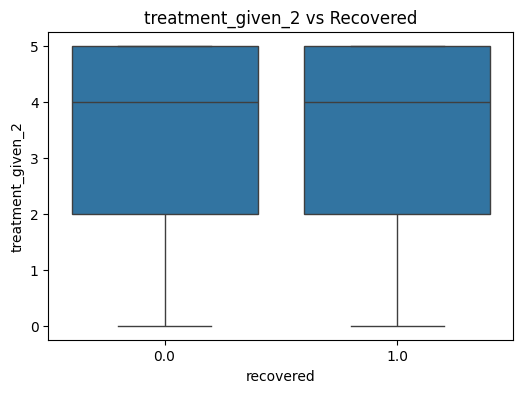

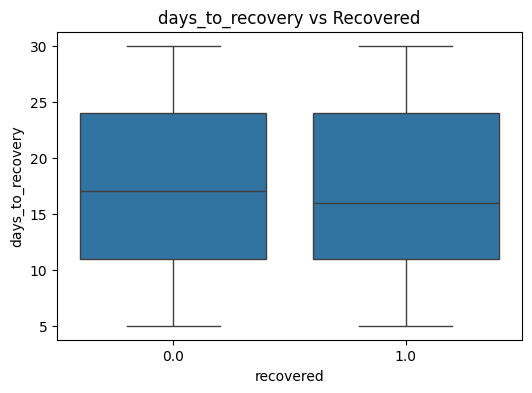

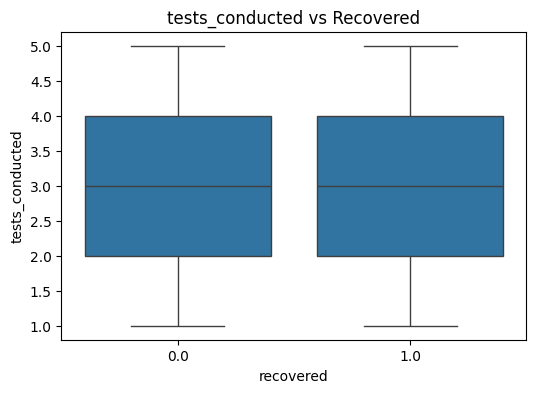

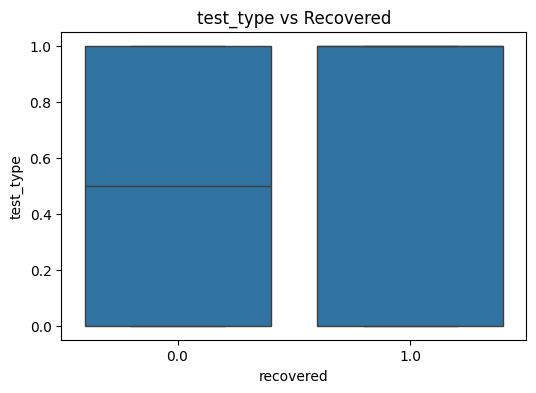

In [101]:
# Boxplots for important features
# List of numerical features to plot (exclude target)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('recovered')  # remove target from features

# Loop through each feature and plot boxplot
for feature in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='recovered', y=feature, data=df)
    plt.title(f"{feature} vs Recovered")
    plt.show()

In [102]:
# -------------------------------
# 5. Feature Engineering
# -------------------------------
# Split features and target
# Drop 'recovered' (the true target) from features. 'target' column was redundant.
X = df.drop('recovered', axis=1)
y = df['recovered'] # Set y to be the 'recovered' column

# Optional: remove highly correlated features to avoid multicollinearity
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X = X.drop(columns=to_drop)
print("\nDropped highly correlated columns:", to_drop)


Dropped highly correlated columns: ['symptoms_3']


In [119]:
# -------------------------------
# 6. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Combine X and y for resampling
train_data = pd.concat([X_train, y_train], axis=1)

# Separate majority and minority classes
# Use y_train.name to access the target column consistently
majority = train_data[train_data[y_train.name] == 0]
minority = train_data[train_data[y_train.name] == 1]

# Upsample minority class
minority_upsampled = resample(minority,
                              replace=True,     # sample with replacement
                              n_samples=len(majority),  # match majority
                              random_state=42)

# Combine back
train_upsampled = pd.concat([majority, minority_upsampled])

# Split features and target again
# Drop y_train.name (which is 'recovered') from the upsampled features
X_train = train_upsampled.drop(y_train.name, axis=1)
y_train = train_upsampled[y_train.name]

In [120]:
# -------------------------------
# 7. Build Pipeline
# -------------------------------
model = LogisticRegression(max_iter=2000, class_weight='balanced')
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', model)
])
#
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94        72
           1       0.88      0.90      0.89        42

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



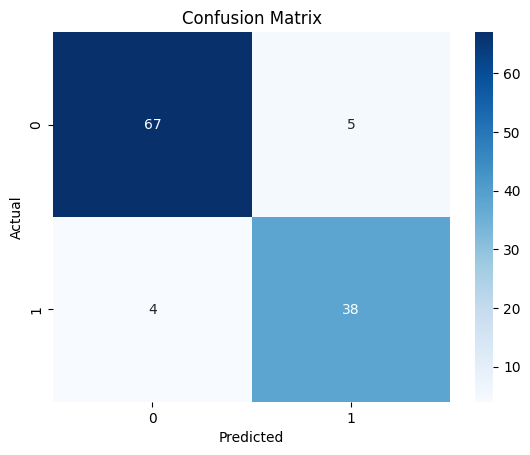

In [122]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()